# Estimação de Parâmetros do Alimentador — Dados com Ruído de Medição

Avalia a capacidade de estimação da matriz de impedância trifásica  
`[r11, r12, r22, r13, r23, r33, x11, x12, x22, x13, x23, x33]`  
quando as medições de tensão, corrente e potência estão contaminadas por ruído realista de PMU/TI.

**Dataset**: `resultados_completos_com_ruido.csv` (10 000 amostras, 60 colunas)

| Grandeza | Ruído aplicado |
|---|---|
| Magnitude de tensão | PMU ±0,2 % + TP ±1 % (total ±1,2 %) |
| Ângulo de tensão | PMU ±0,2 crad + TP ±1,2 crad |
| Magnitude de corrente | PMU ±0,2 % + TC ±1 % (total ±1,2 %) |
| Ângulo de corrente | PMU ±0,2 crad + TC ±1,8 crad |
| Potências P, Q | ±20 % variação de carga |

**Objetivo**: comparar o desempenho de cada modelo com e sem ruído nas features,  
para todos os targets, usando a mesma configuração de CV (3-fold, mesmos hiperparâmetros).

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings

from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import (
    GradientBoostingRegressor,
    RandomForestRegressor,
    ExtraTreesRegressor,
)
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.feature_selection import mutual_info_regression

warnings.filterwarnings('ignore')

SEED = 42


def mape_per_target(y_true, y_pred):
    """MAPE (%) calculado coluna a coluna."""
    return np.mean(np.abs((y_true - y_pred) / y_true), axis=0) * 100


def rmse_pct_per_target(y_true, y_pred):
    """RMSE normalizado pela média do target (%), coluna a coluna."""
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2, axis=0))
    return rmse / np.mean(np.abs(y_true), axis=0) * 100


def run_cv(models, X, y, n_splits=3):
    """KFold-CV para todos os modelos. Retorna MAPE, RMSE% e erros OOF por target."""
    cv = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    cv_results = {}

    for name, model in models.items():
        print(f'  Treinando {name}...')
        mae_folds, rmse_folds, mape_folds = [], [], []
        oof_pred = np.zeros_like(y, dtype=float)

        for train_idx, val_idx in cv.split(X):
            X_tr, X_val = X[train_idx], X[val_idx]
            y_tr, y_val = y[train_idx], y[val_idx]

            pipe = Pipeline([('scaler', StandardScaler()), ('model', clone(model))])
            pipe.fit(X_tr, y_tr)
            y_hat = pipe.predict(X_val)
            oof_pred[val_idx] = y_hat

            mae_folds.append(mean_absolute_error(y_val, y_hat, multioutput='raw_values'))
            rmse_folds.append(np.sqrt(mean_squared_error(y_val, y_hat, multioutput='raw_values')))
            mape_folds.append(mape_per_target(y_val, y_hat))

        mae_folds  = np.array(mae_folds)
        rmse_folds = np.array(rmse_folds)
        mape_folds = np.array(mape_folds)

        rmse_pct_oof = rmse_pct_per_target(y, oof_pred)
        rel_errors   = np.abs((y - oof_pred) / y) * 100

        cv_results[name] = {
            'mae_mean':   mae_folds.mean(axis=0),
            'mae_std':    mae_folds.std(axis=0),
            'rmse_mean':  rmse_folds.mean(axis=0),
            'rmse_std':   rmse_folds.std(axis=0),
            'mape_mean':  mape_folds.mean(axis=0),
            'mape_std':   mape_folds.std(axis=0),
            'rmse_pct':   rmse_pct_oof,
            'rel_errors': rel_errors,
        }

        print(f'    MAPE={mape_folds.mean():.4f}%  RMSE%={rmse_pct_oof.mean():.4f}%')

    return cv_results

## 1. Carga e inspeção dos dados

In [28]:
df = pd.read_csv('Dados14barras/resultados_completos_com_ruido.csv')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (10000, 60)


,r11,r12,r22,r13,r23,r33,x11,x12,x22,x13,...,r22_noisy,r13_noisy,r23_noisy,r33_noisy,x11_noisy,x12_noisy,x22_noisy,x13_noisy,x23_noisy,x33_noisy
0,0.347844,0.155813,0.334539,0.158830,0.151783,0.343622,1.032914,0.492856,1.061910,0.423621,...,0.359286,0.167502,0.161011,0.322405,1.029298,0.53225,0.897065,0.451157,0.354676,1.151118
1,0.347276,0.156226,0.341095,0.157745,0.154151,0.342203,1.010191,0.493998,1.033069,0.423300,...,0.359286,0.167502,0.161011,0.322405,1.029298,0.53225,0.897065,0.451157,0.354676,1.151118
2,0.342861,0.155914,0.336783,0.157673,0.151452,0.344504,1.032487,0.495806,1.041401,0.424497,...,0.359286,0.167502,0.161011,0.322405,1.029298,0.53225,0.897065,0.451157,0.354676,1.151118


In [29]:
print('Colunas originais (48):')
print([c for c in df.columns if not c.endswith('_noisy')])
print()
print('Colunas com parâmetros ruidosos (12):')
print([c for c in df.columns if c.endswith('_noisy')])

Colunas originais (48):
['r11', 'r12', 'r22', 'r13', 'r23', 'r33', 'x11', 'x12', 'x22', 'x13', 'x23', 'x33', 'P1_faseA', 'Q1_faseA', 'P1_faseB', 'Q1_faseB', 'P1_faseC', 'Q1_faseC', 'P2_faseA', 'Q2_faseA', 'P2_faseB', 'Q2_faseB', 'P2_faseC', 'Q2_faseC', 'V1_mag_RG60', 'V1_ang_RG60', 'V2_mag_RG60', 'V2_ang_RG60', 'V3_mag_RG60', 'V3_ang_RG60', 'V1_mag_632', 'V1_ang_632', 'V2_mag_632', 'V2_ang_632', 'V3_mag_632', 'V3_ang_632', 'I1_mag_faseA', 'I1_ang_faseA', 'I1_mag_faseB', 'I1_ang_faseB', 'I1_mag_faseC', 'I1_ang_faseC', 'I2_mag_faseA', 'I2_ang_faseA', 'I2_mag_faseB', 'I2_ang_faseB', 'I2_mag_faseC', 'I2_ang_faseC']

Colunas com parâmetros ruidosos (12):
['r11_noisy', 'r12_noisy', 'r22_noisy', 'r13_noisy', 'r23_noisy', 'r33_noisy', 'x11_noisy', 'x12_noisy', 'x22_noisy', 'x13_noisy', 'x23_noisy', 'x33_noisy']


## 2. Definição de features e targets

In [30]:
TARGETS = ['r11','r12','r22','r13','r23','r33',
           'x11','x12','x22','x13','x23','x33']

FEATURES = [
    'P1_faseA', 'Q1_faseA', 'P1_faseB', 'Q1_faseB', 'P1_faseC', 'Q1_faseC',
    'P2_faseA', 'Q2_faseA', 'P2_faseB', 'Q2_faseB', 'P2_faseC', 'Q2_faseC',
    'V1_mag_RG60', 'V1_ang_RG60', 'V2_mag_RG60', 'V2_ang_RG60', 'V3_mag_RG60', 'V3_ang_RG60',
    'I1_mag_faseA', 'I1_ang_faseA', 'I1_mag_faseB', 'I1_ang_faseB', 'I1_mag_faseC', 'I1_ang_faseC',
]

print(f'Features ({len(FEATURES)}): {FEATURES}')
print(f'Targets  ({len(TARGETS)}): {TARGETS}')

Features (24): ['P1_faseA', 'Q1_faseA', 'P1_faseB', 'Q1_faseB', 'P1_faseC', 'Q1_faseC', 'P2_faseA', 'Q2_faseA', 'P2_faseB', 'Q2_faseB', 'P2_faseC', 'Q2_faseC', 'V1_mag_RG60', 'V1_ang_RG60', 'V2_mag_RG60', 'V2_ang_RG60', 'V3_mag_RG60', 'V3_ang_RG60', 'I1_mag_faseA', 'I1_ang_faseA', 'I1_mag_faseB', 'I1_ang_faseB', 'I1_mag_faseC', 'I1_ang_faseC']
Targets  (12): ['r11', 'r12', 'r22', 'r13', 'r23', 'r33', 'x11', 'x12', 'x22', 'x13', 'x23', 'x33']


In [31]:
print('Estatísticas dos targets (ground-truth — parâmetros reais):')
df[TARGETS].describe().round(5)

Estatísticas dos targets (ground-truth — parâmetros reais):


,r11,r12,r22,r13,r23,r33,x11,x12,x22,x13,x23,x33
count,10000.00000,10000.00000,10000.00000,10000.00000,10000.00000,10000.00000,10000.00000,10000.00000,10000.00000,10000.00000,10000.00000,10000.00000
mean,0.34651,0.15599,0.33751,0.15796,0.15347,0.34142,1.01790,0.50169,1.04786,0.42356,0.38488,1.03485
std,0.00346,0.00155,0.00336,0.00156,0.00154,0.00337,0.01026,0.00503,0.01053,0.00421,0.00383,0.01021
min,0.33448,0.15057,0.32355,0.15142,0.14702,0.32655,0.98215,0.48358,1.01149,0.40838,0.36891,0.99419
25%,0.34418,0.15495,0.33526,0.15689,0.15243,0.33915,1.01105,0.49830,1.04067,0.42067,0.38226,1.02788
50%,0.34649,0.15601,0.33751,0.15796,0.15349,0.34141,1.01774,0.50170,1.04793,0.42354,0.38486,1.03480
75%,0.34881,0.15703,0.33978,0.15900,0.15451,0.34371,1.02494,0.50515,1.05502,0.42644,0.38745,1.04184
max,0.35993,0.16199,0.35071,0.16370,0.15942,0.35461,1.06180,0.52163,1.09792,0.44119,0.40047,1.07207


## 3. Correlação features × targets

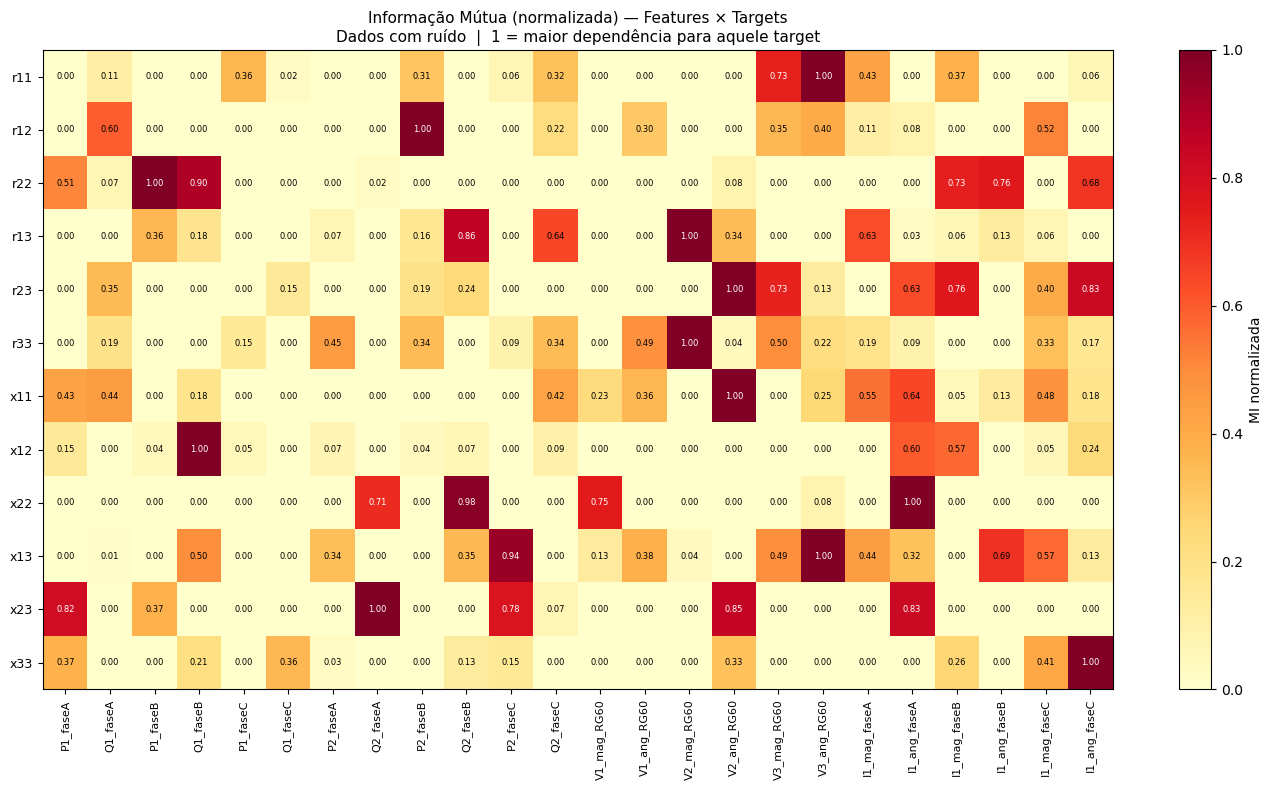


Feature com maior MI por target:


r11     V3_ang_RG60
r12        P2_faseB
r22        P1_faseB
r13     V2_mag_RG60
r23     V2_ang_RG60
r33     V2_mag_RG60
x11     V2_ang_RG60
x12        Q1_faseB
x22    I1_ang_faseA
x13     V3_ang_RG60
x23        Q2_faseA
x33    I1_ang_faseC
Name: Feature mais informativa, dtype: object

In [32]:
X_all = df[FEATURES].values
y_all = df[TARGETS].values

# MI para cada target separadamente (mutual_info_regression opera sobre um único y)
mi_matrix = np.array([
    mutual_info_regression(X_all, y_all[:, j], random_state=SEED)
    for j in range(len(TARGETS))
]).T  # (n_features, n_targets)

# Normaliza por coluna para escala 0-1 (facilita comparação entre targets)
mi_norm = mi_matrix / mi_matrix.max(axis=0, keepdims=True)

df_mi = pd.DataFrame(mi_norm, index=FEATURES, columns=TARGETS)

fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(df_mi.T.values, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)

ax.set_xticks(range(len(FEATURES)))
ax.set_xticklabels(FEATURES, rotation=90, fontsize=8)
ax.set_yticks(range(len(TARGETS)))
ax.set_yticklabels(TARGETS, fontsize=9)
ax.set_title('Informação Mútua (normalizada) — Features × Targets\n'
             'Dados com ruído  |  1 = maior dependência para aquele target', fontsize=11)

for j in range(len(TARGETS)):
    for i in range(len(FEATURES)):
        ax.text(i, j, f'{df_mi.iloc[i, j]:.2f}',
                ha='center', va='center', fontsize=6,
                color='black' if df_mi.iloc[i, j] < 0.7 else 'white')

plt.colorbar(im, ax=ax, label='MI normalizada')
plt.tight_layout()
plt.show()

print('\nFeature com maior MI por target:')
display(df_mi.idxmax(axis=0).rename('Feature mais informativa'))

## 4. Modelos de estimação

In [33]:
models = {
    'Ridge': Ridge(alpha=1.0),
    'RandomForest': MultiOutputRegressor(
        RandomForestRegressor(
            n_estimators=100, max_depth=20, max_samples=0.8,
            n_jobs=-1, random_state=SEED,
        ),
        n_jobs=-1,
    ),
    'ExtraTrees': MultiOutputRegressor(
        ExtraTreesRegressor(
            n_estimators=100, max_depth=20,
            n_jobs=-1, random_state=SEED,
        ),
        n_jobs=-1,
    ),
    'GradientBoosting': MultiOutputRegressor(
        GradientBoostingRegressor(
            n_estimators=100, max_depth=4, learning_rate=0.05,
            subsample=0.8, random_state=SEED,
        ),
        n_jobs=-1,
    ),
}

## 5. Baseline — dados limpos (mesmos modelos e hiperparâmetros)

In [34]:
df_clean = pd.read_csv('Dados14barras/resultados_completos_0.01.csv')
X_clean = df_clean[FEATURES].values
y_clean = df_clean[TARGETS].values

print('=== Baseline: dados limpos — validação cruzada (3-fold) ===')
cv_results_clean = run_cv(models, X_clean, y_clean, n_splits=3)

=== Baseline: dados limpos — validação cruzada (3-fold) ===
  Treinando Ridge...
    MAPE=0.2718%  RMSE%=0.3405%
  Treinando RandomForest...
    MAPE=0.5224%  RMSE%=0.6545%
  Treinando ExtraTrees...
    MAPE=0.5289%  RMSE%=0.6626%
  Treinando GradientBoosting...
    MAPE=0.5188%  RMSE%=0.6502%


## 6. Dados com ruído — validação cruzada

In [35]:
X_noisy = df[FEATURES].values
y       = df[TARGETS].values

print('=== Dados com ruído — validação cruzada (3-fold) ===')
cv_results_noisy = run_cv(models, X_noisy, y, n_splits=3)

=== Dados com ruído — validação cruzada (3-fold) ===
  Treinando Ridge...
    MAPE=0.7956%  RMSE%=0.9960%
  Treinando RandomForest...
    MAPE=0.7958%  RMSE%=0.9961%
  Treinando ExtraTrees...
    MAPE=0.7982%  RMSE%=0.9991%
  Treinando GradientBoosting...
    MAPE=0.7931%  RMSE%=0.9927%


In [36]:
rows = []
for name in models:
    rows.append({
        'Modelo':             name,
        'Limpo MAPE %':       round(cv_results_clean[name]['mape_mean'].mean(),  4),
        'Limpo RMSE%':        round(cv_results_clean[name]['rmse_pct'].mean(),   4),
        'Com Ruído MAPE %':   round(cv_results_noisy[name]['mape_mean'].mean(),  4),
        'Com Ruído RMSE%':    round(cv_results_noisy[name]['rmse_pct'].mean(),   4),
    })

df_summary = pd.DataFrame(rows).set_index('Modelo')
print('Resumo geral — Limpo vs. Com Ruído')
display(df_summary)

Resumo geral — Limpo vs. Com Ruído


,Limpo MAPE %,Limpo RMSE%,Com Ruído MAPE %,Com Ruído RMSE%
Modelo,,,,
Ridge,0.2718,0.3405,0.7956,0.9960
RandomForest,0.5224,0.6545,0.7958,0.9961
ExtraTrees,0.5289,0.6626,0.7982,0.9991
GradientBoosting,0.5188,0.6502,0.7931,0.9927


In [37]:
print('MAPE % por target — todos os modelos — Dados com ruído')
rows_mape = {name: cv_results_noisy[name]['mape_mean'] for name in models}
display(pd.DataFrame(rows_mape, index=TARGETS).round(4))

print('\nRMSE% por target — todos os modelos — Dados com ruído')
rows_rmse_pct = {name: cv_results_noisy[name]['rmse_pct'] for name in models}
display(pd.DataFrame(rows_rmse_pct, index=TARGETS).round(4))

MAPE % por target — todos os modelos — Dados com ruído


,Ridge,RandomForest,ExtraTrees,GradientBoosting
r11,0.7974,0.8011,0.8039,0.7983
r12,0.7960,0.8022,0.8029,0.7977
r22,0.7947,0.7996,0.7995,0.7980
r13,0.7923,0.7958,0.7979,0.7940
r23,0.8027,0.8067,0.8104,0.8059
r33,0.7866,0.7902,0.7918,0.7886
x11,0.7984,0.7865,0.7889,0.7821
x12,0.8032,0.8018,0.8024,0.7988
x22,0.8012,0.8028,0.8055,0.8001
x13,0.7947,0.7970,0.7991,0.7943



RMSE% por target — todos os modelos — Dados com ruído


,Ridge,RandomForest,ExtraTrees,GradientBoosting
r11,0.9990,1.0041,1.0072,1.0009
r12,0.9987,1.0062,1.0074,1.0013
r22,0.9978,1.0035,1.0039,1.0006
r13,0.9916,0.9957,0.9988,0.9936
r23,1.0050,1.0099,1.0133,1.0065
r33,0.9871,0.9916,0.9937,0.9900
x11,0.9972,0.9808,0.9845,0.9757
x12,1.0047,1.0026,1.0044,0.9997
x22,1.0045,1.0049,1.0080,1.0015
x13,0.9939,0.9980,0.9994,0.9937


In [38]:
# RMSE% por target — todos os modelos — Limpo vs. Com Ruído
for dataset_label, cv_res in [
    ('Limpo',      cv_results_clean),
    ('Com Ruído',  cv_results_noisy),
]:
    df_rmse_pct = pd.DataFrame(
        {name: cv_res[name]['rmse_pct'].round(4) for name in models},
        index=TARGETS,
    )
    print(f'\nRMSE% (RMSE / média_real × 100) — {dataset_label}:')
    display(df_rmse_pct)


RMSE% (RMSE / média_real × 100) — Limpo:


,Ridge,RandomForest,ExtraTrees,GradientBoosting
r11,0.3869,0.6661,0.6721,0.6575
r12,0.3763,0.9686,0.9832,0.9640
r22,0.1602,0.8722,0.8879,0.8753
r13,0.8280,0.9396,0.9461,0.9263
r23,0.6321,0.9733,0.9824,0.9613
r33,0.5156,0.6735,0.6781,0.6603
x11,0.1029,0.2510,0.2532,0.2503
x12,0.1709,0.5415,0.5577,0.5503
x22,0.0390,0.4045,0.4117,0.4040
x13,0.4207,0.6239,0.6264,0.6185



RMSE% (RMSE / média_real × 100) — Com Ruído:


,Ridge,RandomForest,ExtraTrees,GradientBoosting
r11,0.9990,1.0041,1.0072,1.0009
r12,0.9987,1.0062,1.0074,1.0013
r22,0.9978,1.0035,1.0039,1.0006
r13,0.9916,0.9957,0.9988,0.9936
r23,1.0050,1.0099,1.0133,1.0065
r33,0.9871,0.9916,0.9937,0.9900
x11,0.9972,0.9808,0.9845,0.9757
x12,1.0047,1.0026,1.0044,0.9997
x22,1.0045,1.0049,1.0080,1.0015
x13,0.9939,0.9980,0.9994,0.9937


## 7. Melhor modelo — dados com ruído

In [39]:
best_name = min(cv_results_noisy, key=lambda n: cv_results_noisy[n]['mape_mean'].mean())
print(f'Melhor modelo (menor MAPE médio): {best_name}')
print(f'  CV MAPE  = {cv_results_noisy[best_name]["mape_mean"].mean():.4f}%')
print(f'  CV RMSE% = {cv_results_noisy[best_name]["rmse_pct"].mean():.4f}%')

best_pipe = Pipeline([('scaler', StandardScaler()), ('model', clone(models[best_name]))])
best_pipe.fit(X_noisy, y)
y_pred = best_pipe.predict(X_noisy)

Melhor modelo (menor MAPE médio): GradientBoosting
  CV MAPE  = 0.7931%
  CV RMSE% = 0.9927%


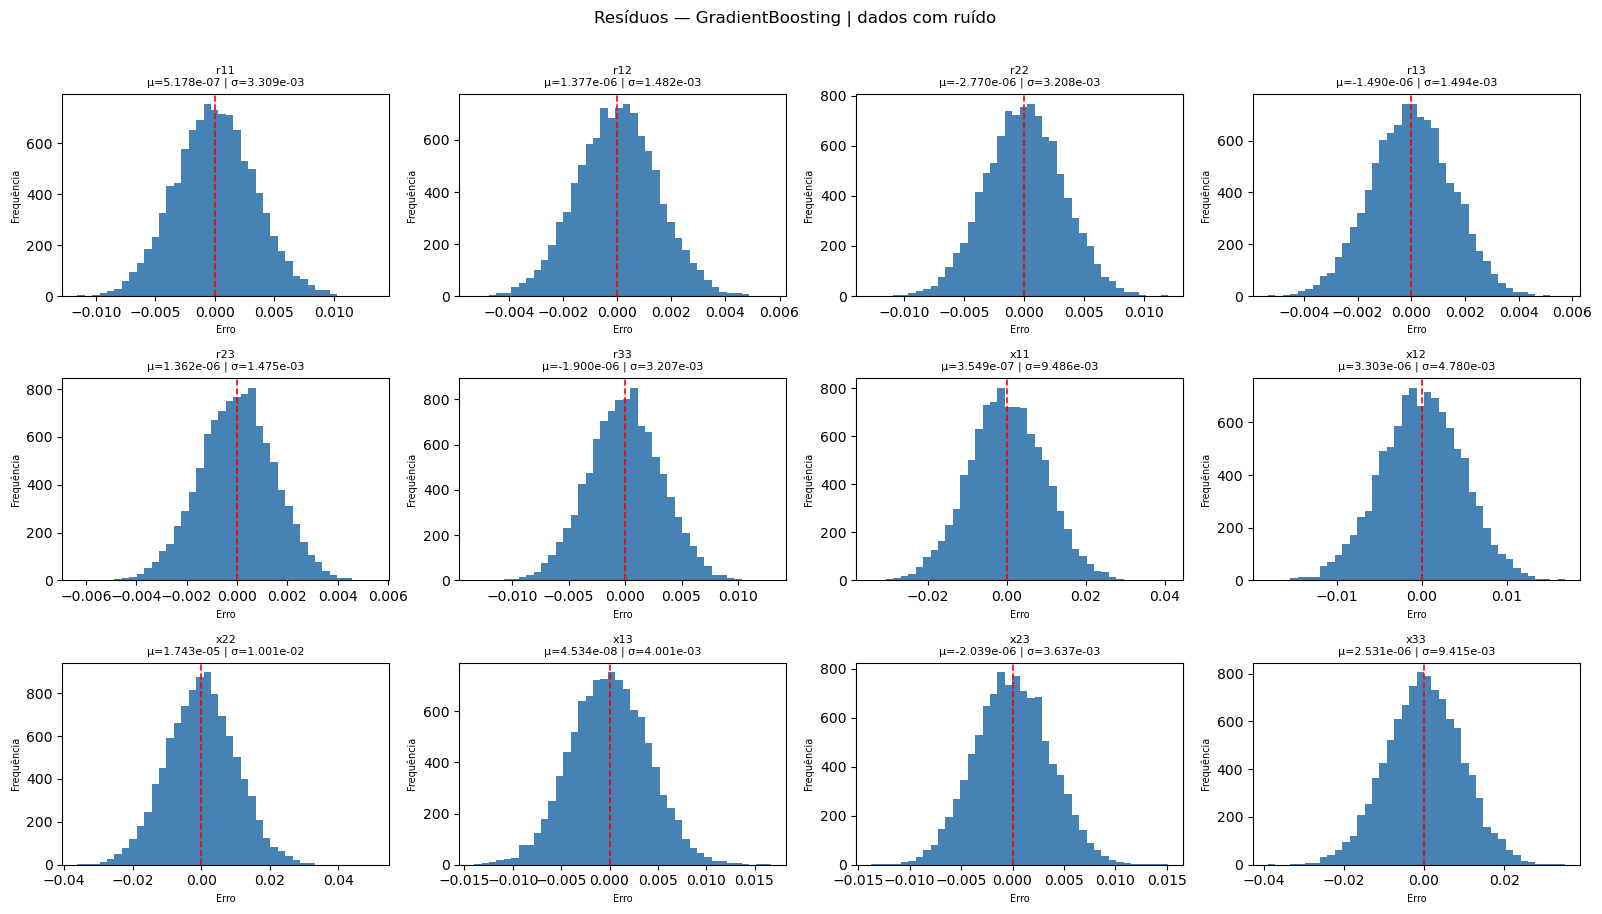

In [40]:
residuals = y - y_pred

fig, axes = plt.subplots(3, 4, figsize=(16, 9))
axes = axes.flatten()
for i, t in enumerate(TARGETS):
    ax = axes[i]
    ax.hist(residuals[:, i], bins=40, color='steelblue', edgecolor='none')
    ax.axvline(0, color='red', lw=1.2, ls='--')
    mu, sigma = residuals[:, i].mean(), residuals[:, i].std()
    ax.set_title(f'{t}\nμ={mu:.3e} | σ={sigma:.3e}', fontsize=8)
    ax.set_xlabel('Erro', fontsize=7)
    ax.set_ylabel('Frequência', fontsize=7)
plt.suptitle(f'Resíduos — {best_name} | dados com ruído', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 8. Comparação completa — Limpo vs. Com Ruído

Todos os modelos × todos os targets.

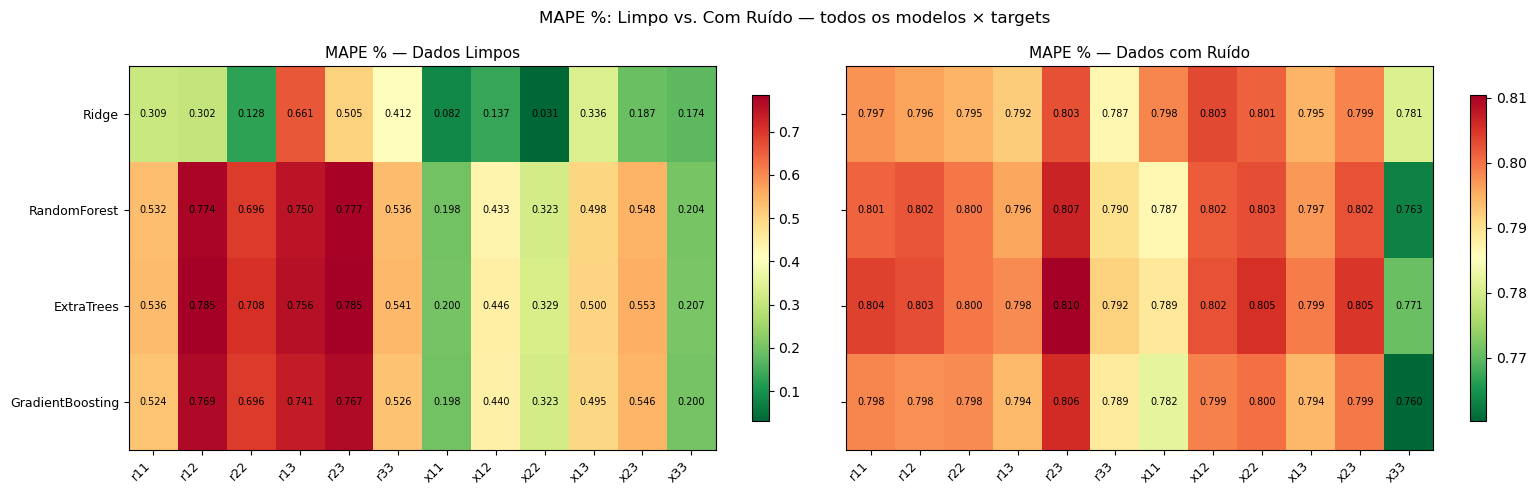

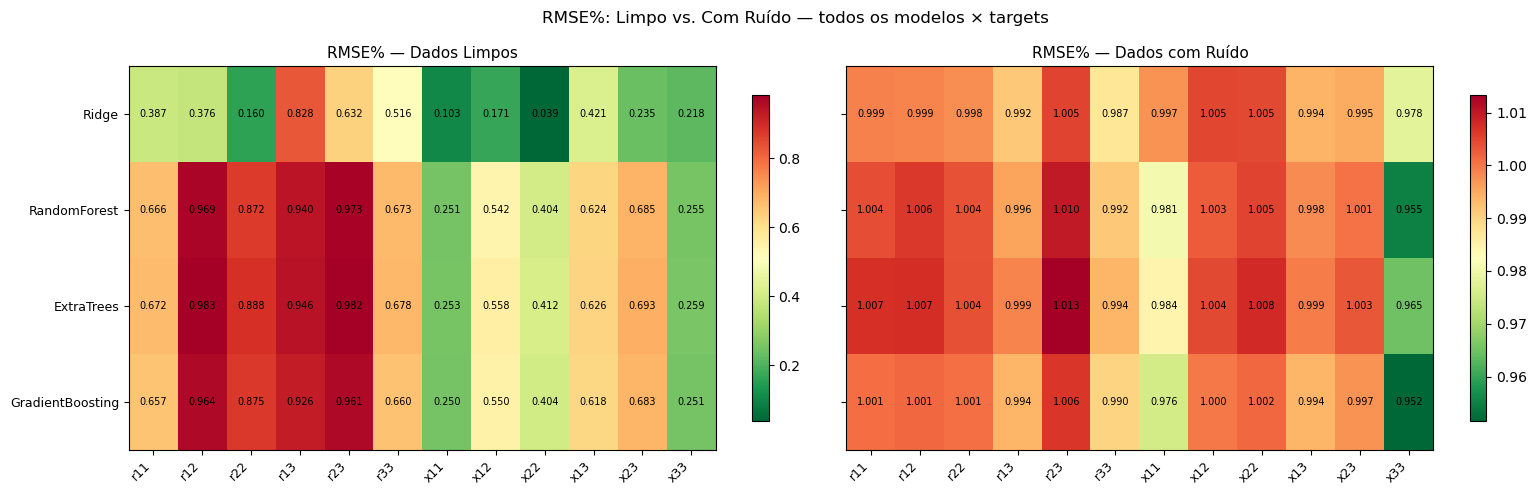

In [41]:
# Heatmaps: MAPE % e RMSE% — Limpo vs. Com Ruído, todos os modelos

for metric, label in [('mape', 'MAPE %'), ('rmse_pct', 'RMSE%')]:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

    for ax, (cv_res, title) in zip(axes, [
        (cv_results_clean, 'Dados Limpos'),
        (cv_results_noisy, 'Dados com Ruído'),
    ]):
        key = 'mape_mean' if metric == 'mape' else 'rmse_pct'
        data = np.array([cv_res[name][key] for name in models])  # (n_models, n_targets)

        im = ax.imshow(data, aspect='auto', cmap='RdYlGn_r',
                       vmin=data.min(), vmax=data.max())
        ax.set_xticks(range(len(TARGETS)))
        ax.set_xticklabels(TARGETS, rotation=45, ha='right', fontsize=9)
        ax.set_yticks(range(len(models)))
        ax.set_yticklabels(list(models.keys()), fontsize=9)
        ax.set_title(f'{label} — {title}', fontsize=11)

        for i in range(len(models)):
            for j in range(len(TARGETS)):
                ax.text(j, i, f'{data[i, j]:.3f}',
                        ha='center', va='center', fontsize=7, color='black')

        plt.colorbar(im, ax=ax, shrink=0.85)

    plt.suptitle(f'{label}: Limpo vs. Com Ruído — todos os modelos × targets', fontsize=12)
    plt.tight_layout()
    plt.show()

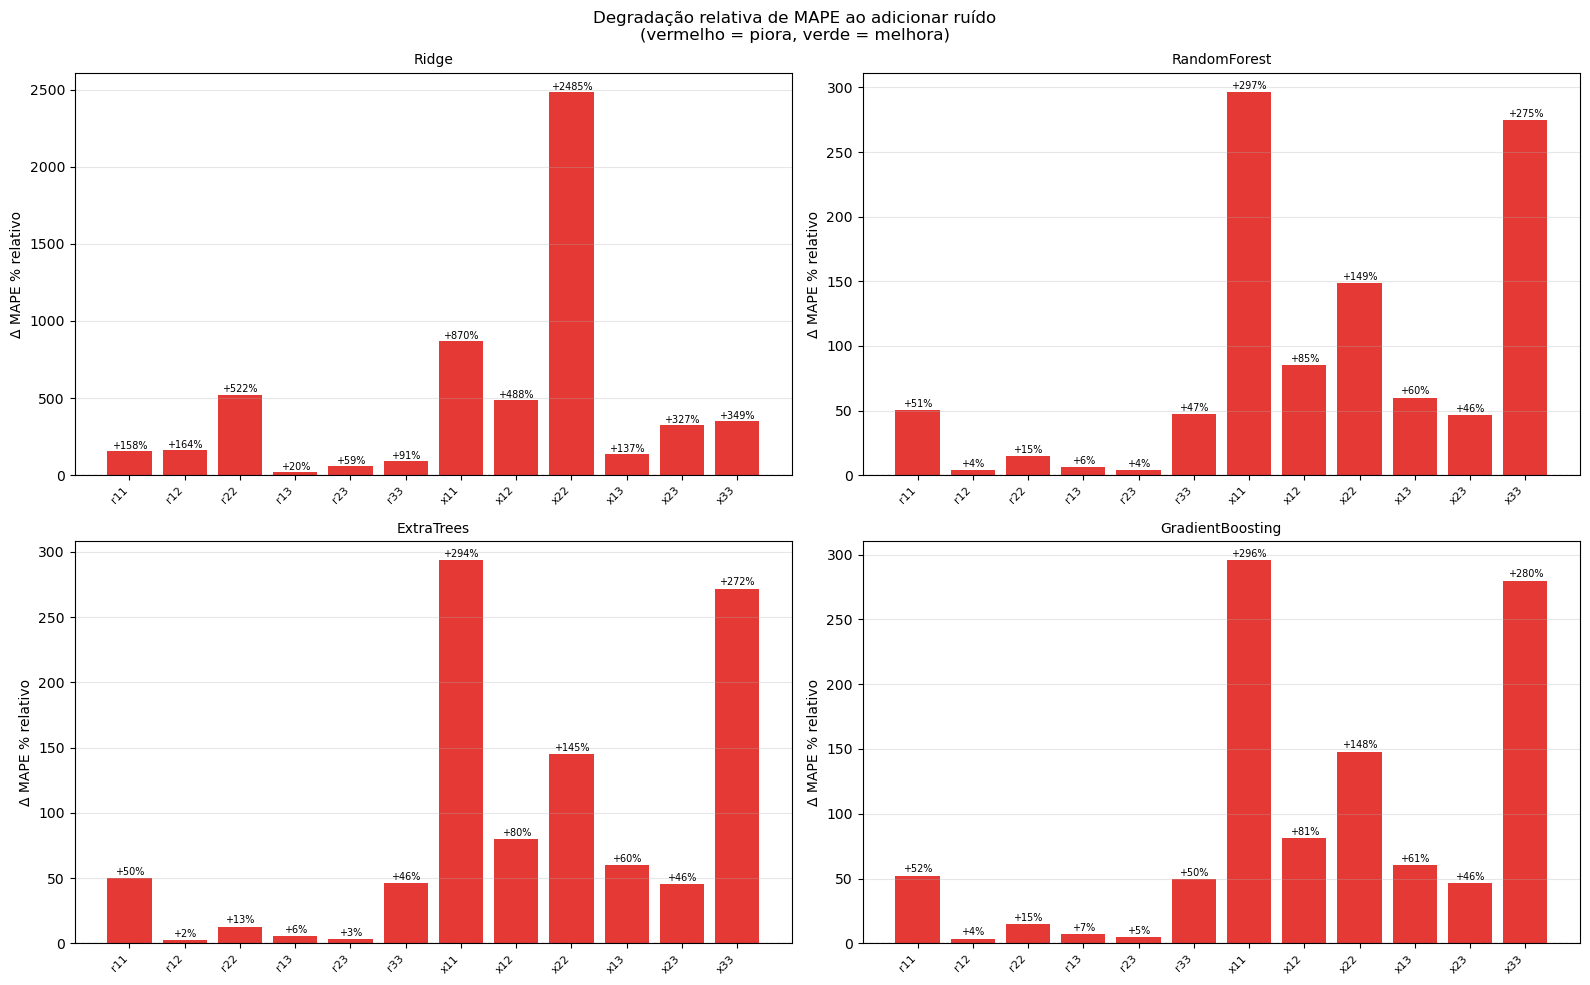

In [42]:
# ── Degradação relativa de MAPE: (ruidoso - limpo) / limpo × 100 ────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, name in zip(axes, models.keys()):
    mape_clean_m = cv_results_clean[name]['mape_mean']
    mape_noisy_m = cv_results_noisy[name]['mape_mean']
    delta = (mape_noisy_m - mape_clean_m) / mape_clean_m * 100

    colors = ['#e53935' if d > 0 else '#43a047' for d in delta]
    bars = ax.bar(TARGETS, delta, color=colors, edgecolor='none')
    ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.set_title(f'{name}', fontsize=10)
    ax.set_ylabel('Δ MAPE % relativo')
    ax.set_xticklabels(TARGETS, rotation=45, ha='right', fontsize=8)
    ax.grid(axis='y', alpha=0.3)

    for bar, d in zip(bars, delta):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + (1 if d >= 0 else -3),
                f'{d:+.0f}%', ha='center', va='bottom', fontsize=7)

plt.suptitle('Degradação relativa de MAPE ao adicionar ruído\n(vermelho = piora, verde = melhora)', fontsize=12)
plt.tight_layout()
plt.show()

In [43]:
# Tabela completa por modelo × target: MAPE e RMSE% (limpo e ruidoso)
for name in models:
    df_cmp = pd.DataFrame({
        'MAPE_limpo':   cv_results_clean[name]['mape_mean'].round(4),
        'MAPE_ruido':   cv_results_noisy[name]['mape_mean'].round(4),
        'Δ_MAPE_%':    ((cv_results_noisy[name]['mape_mean'] - cv_results_clean[name]['mape_mean'])
                         / cv_results_clean[name]['mape_mean'] * 100).round(1),
        'RMSE%_limpo':  cv_results_clean[name]['rmse_pct'].round(4),
        'RMSE%_ruido':  cv_results_noisy[name]['rmse_pct'].round(4),
        'Δ_RMSE%':     (cv_results_noisy[name]['rmse_pct'] - cv_results_clean[name]['rmse_pct']).round(4),
    }, index=TARGETS)
    print(f'\n── {name} ──')
    display(df_cmp)


── Ridge ──


,MAPE_limpo,MAPE_ruido,Δ_MAPE_%,RMSE%_limpo,RMSE%_ruido,Δ_RMSE%
r11,0.3086,0.7974,158.4,0.3869,0.9990,0.6121
r12,0.3016,0.7960,164.0,0.3763,0.9987,0.6224
r22,0.1278,0.7947,522.0,0.1602,0.9978,0.8375
r13,0.6611,0.7923,19.8,0.8280,0.9916,0.1636
r23,0.5046,0.8027,59.1,0.6321,1.0050,0.3729
r33,0.4119,0.7866,91.0,0.5156,0.9871,0.4715
x11,0.0823,0.7984,870.3,0.1029,0.9972,0.8943
x12,0.1365,0.8032,488.3,0.1709,1.0047,0.8338
x22,0.0310,0.8012,2484.8,0.0390,1.0045,0.9655
x13,0.3358,0.7947,136.7,0.4207,0.9939,0.5732



── RandomForest ──


,MAPE_limpo,MAPE_ruido,Δ_MAPE_%,RMSE%_limpo,RMSE%_ruido,Δ_RMSE%
r11,0.5322,0.8011,50.5,0.6661,1.0041,0.3380
r12,0.7738,0.8022,3.7,0.9686,1.0062,0.0375
r22,0.6958,0.7996,14.9,0.8722,1.0035,0.1313
r13,0.7497,0.7958,6.1,0.9396,0.9957,0.0561
r23,0.7766,0.8067,3.9,0.9733,1.0099,0.0367
r33,0.5364,0.7902,47.3,0.6735,0.9916,0.3181
x11,0.1983,0.7865,296.5,0.2510,0.9808,0.7298
x12,0.4327,0.8018,85.3,0.5415,1.0026,0.4611
x22,0.3229,0.8028,148.6,0.4045,1.0049,0.6005
x13,0.4980,0.7970,60.1,0.6239,0.9980,0.3740



── ExtraTrees ──


,MAPE_limpo,MAPE_ruido,Δ_MAPE_%,RMSE%_limpo,RMSE%_ruido,Δ_RMSE%
r11,0.5365,0.8039,49.9,0.6721,1.0072,0.3351
r12,0.7847,0.8029,2.3,0.9832,1.0074,0.0242
r22,0.7084,0.7995,12.9,0.8879,1.0039,0.1160
r13,0.7562,0.7979,5.5,0.9461,0.9988,0.0527
r23,0.7849,0.8104,3.3,0.9824,1.0133,0.0309
r33,0.5410,0.7918,46.4,0.6781,0.9937,0.3155
x11,0.2005,0.7889,293.5,0.2532,0.9845,0.7313
x12,0.4457,0.8024,80.0,0.5577,1.0044,0.4467
x22,0.3289,0.8055,144.9,0.4117,1.0080,0.5963
x13,0.5000,0.7991,59.8,0.6264,0.9994,0.3730



── GradientBoosting ──


,MAPE_limpo,MAPE_ruido,Δ_MAPE_%,RMSE%_limpo,RMSE%_ruido,Δ_RMSE%
r11,0.5242,0.7983,52.3,0.6575,1.0009,0.3435
r12,0.7691,0.7977,3.7,0.9640,1.0013,0.0373
r22,0.6960,0.7980,14.7,0.8753,1.0006,0.1253
r13,0.7406,0.7940,7.2,0.9263,0.9936,0.0673
r23,0.7670,0.8059,5.1,0.9613,1.0065,0.0451
r33,0.5263,0.7886,49.8,0.6603,0.9900,0.3297
x11,0.1977,0.7821,295.6,0.2503,0.9757,0.7254
x12,0.4405,0.7988,81.3,0.5503,0.9997,0.4494
x22,0.3228,0.8001,147.9,0.4040,1.0015,0.5975
x13,0.4948,0.7943,60.5,0.6185,0.9937,0.3752


## 9. Avaliação no conjunto de teste (hold-out 20%)

In [44]:
results_holdout = []

for dataset_label, X_ds, y_ds in [
    ('Limpo',      X_clean, y_clean),
    ('Com Ruído',  X_noisy, y),
]:
    X_tr, X_te, y_tr, y_te = train_test_split(X_ds, y_ds, test_size=0.2, random_state=SEED)
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)

    for name, model in models.items():
        m = clone(model)
        m.fit(X_tr_s, y_tr)
        y_pred_h = m.predict(X_te_s)

        results_holdout.append({
            'Dataset':      dataset_label,
            'Modelo':       name,
            'Teste MAE':    round(mean_absolute_error(y_te, y_pred_h, multioutput='raw_values').mean(), 6),
            'Teste RMSE%':  round(rmse_pct_per_target(y_te, y_pred_h).mean(), 4),
            'Teste MAPE%':  round(mape_per_target(y_te, y_pred_h).mean(), 4),
        })

df_holdout = pd.DataFrame(results_holdout).set_index(['Dataset', 'Modelo'])
print('Resultados no conjunto de teste (hold-out 20%):')
display(df_holdout.sort_values('Teste MAPE%'))

Resultados no conjunto de teste (hold-out 20%):


Teste MAE  Teste RMSE%  Teste MAPE%
Dataset   Modelo                                               
Limpo     Ridge              0.000900       0.3343       0.2678
          GradientBoosting   0.001938       0.6467       0.5162
          RandomForest       0.001944       0.6501       0.5194
          ExtraTrees         0.001976       0.6598       0.5275
Com Ruído GradientBoosting   0.003860       0.9913       0.7891
          RandomForest       0.003873       0.9941       0.7913
          Ridge              0.003897       0.9952       0.7924
          ExtraTrees         0.003900       0.9989       0.7953

## 10. Distribuição dos erros no conjunto de teste — análise dos casos críticos (> 5%)

In [45]:
THRESHOLD = 3.5  # %

# Treina melhor modelo no conjunto de treino e avalia no teste (dados com ruído)
X_tr, X_te, y_tr, y_te = train_test_split(X_noisy, y, test_size=0.2, random_state=SEED)
scaler_te = StandardScaler()
X_tr_s = scaler_te.fit_transform(X_tr)
X_te_s = scaler_te.transform(X_te)

m_te = clone(models[best_name])
m_te.fit(X_tr_s, y_tr)
y_pred_te = m_te.predict(X_te_s)

rel_err_te = np.abs((y_te - y_pred_te) / y_te) * 100  # (n_test, n_targets)

# ── Tabela resumo por target ──────────────────────────────────────────────────
df_err = pd.DataFrame({
    'Mediana %':                   np.median(rel_err_te, axis=0).round(3),
    'Média %':                     rel_err_te.mean(axis=0).round(3),
    'p90 %':                       np.percentile(rel_err_te, 90, axis=0).round(3),
    'p99 %':                       np.percentile(rel_err_te, 99, axis=0).round(3),
    f'% amostras > {THRESHOLD}%': ((rel_err_te > THRESHOLD).mean(axis=0) * 100).round(1),
}, index=TARGETS)

print(f'Distribuição dos erros relativos no teste — {best_name} | dados com ruído')
display(df_err)
print(f'\nTotal de amostras no teste: {len(y_te)}')
print(f'Amostras com pelo menos um target > {THRESHOLD}%: '
      f'{(rel_err_te > THRESHOLD).any(axis=1).sum()} '
      f'({(rel_err_te > THRESHOLD).any(axis=1).mean():.1%})')

Distribuição dos erros relativos no teste — GradientBoosting | dados com ruído


,Mediana %,Média %,p90 %,p99 %,% amostras > 3.5%
r11,0.687,0.812,1.694,2.715,0.0
r12,0.669,0.799,1.679,2.742,0.0
r22,0.660,0.801,1.657,2.625,0.0
r13,0.666,0.786,1.642,2.551,0.1
r23,0.675,0.798,1.654,2.389,0.0
r33,0.649,0.784,1.626,2.680,0.1
x11,0.655,0.775,1.563,2.444,0.1
x12,0.630,0.769,1.615,2.466,0.1
x22,0.661,0.792,1.646,2.577,0.2
x13,0.678,0.785,1.601,2.570,0.0



Total de amostras no teste: 2000
Amostras com pelo menos um target > 3.5%: 18 (0.9%)


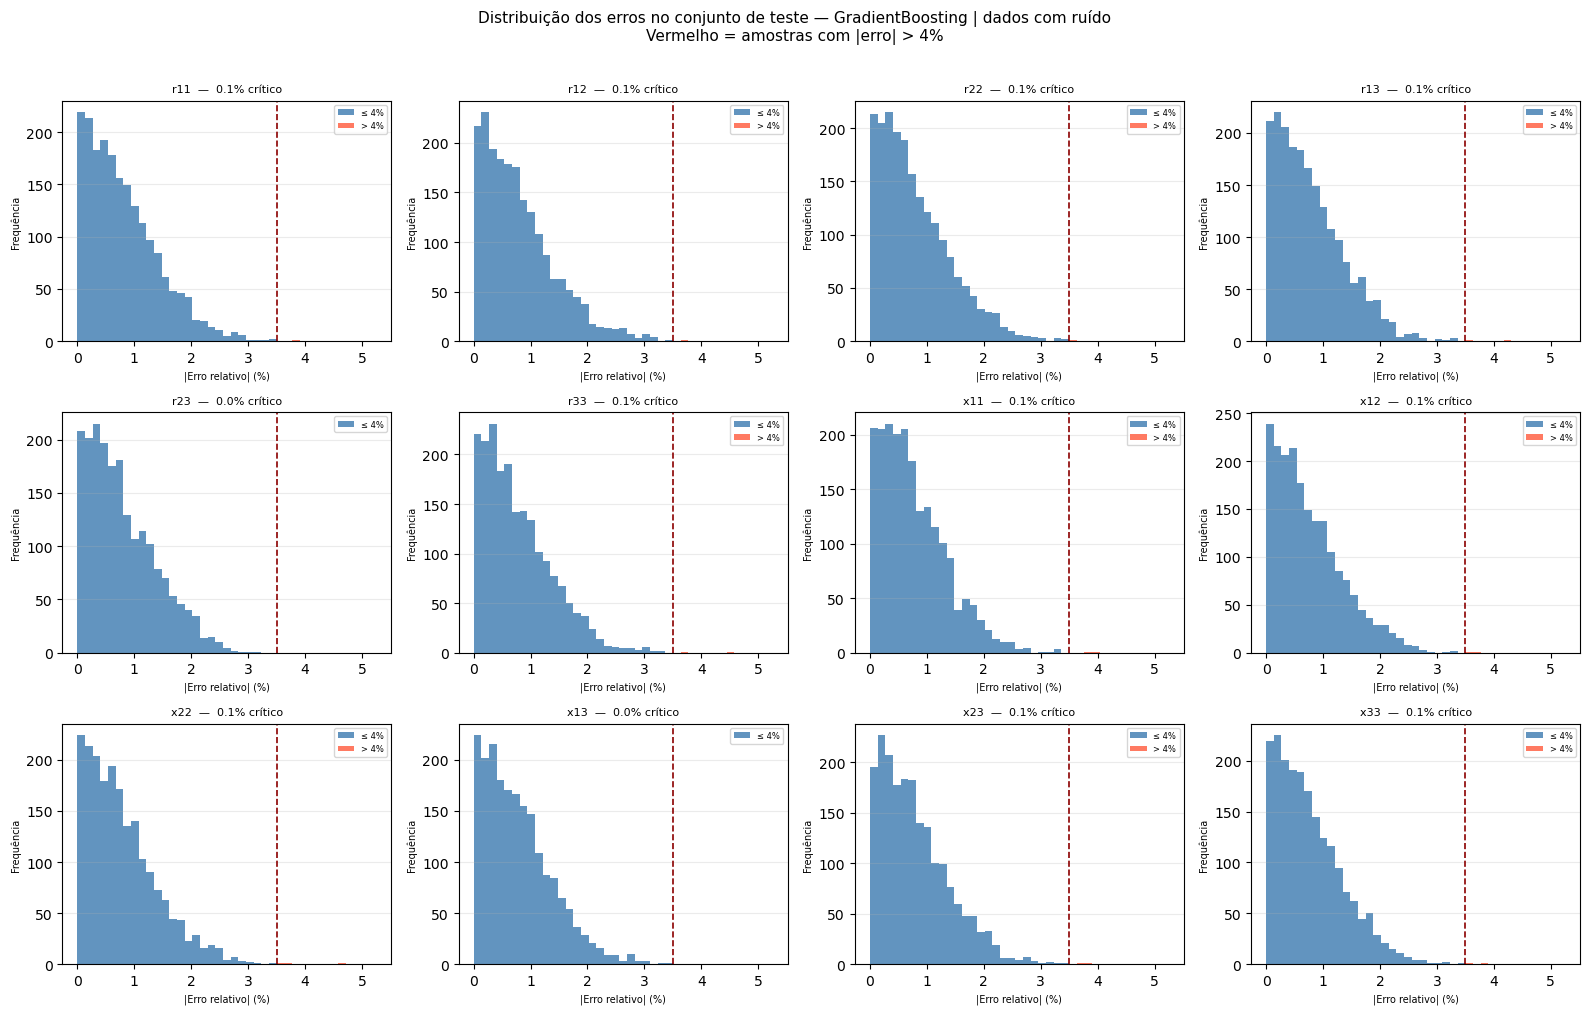

In [46]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, t in enumerate(TARGETS):
    ax = axes[i]
    errs = rel_err_te[:, i]
    below = errs[errs <= THRESHOLD]
    above = errs[errs >  THRESHOLD]

    bins = np.linspace(0, max(errs.max(), THRESHOLD * 1.5), 40)
    ax.hist(below, bins=bins, color='steelblue', alpha=0.85, label=f'≤ {THRESHOLD:.0f}%')
    if len(above):
        ax.hist(above, bins=bins, color='tomato', alpha=0.85, label=f'> {THRESHOLD:.0f}%')

    ax.axvline(THRESHOLD, color='darkred', ls='--', lw=1.2)
    pct_above = (errs > THRESHOLD).mean() * 100
    ax.set_title(f'{t}  —  {pct_above:.1f}% crítico', fontsize=8)
    ax.set_xlabel('|Erro relativo| (%)', fontsize=7)
    ax.set_ylabel('Frequência', fontsize=7)
    ax.legend(fontsize=6, loc='upper right')
    ax.grid(axis='y', alpha=0.25)

plt.suptitle(
    f'Distribuição dos erros no conjunto de teste — {best_name} | dados com ruído\n'
    f'Vermelho = amostras com |erro| > {THRESHOLD:.0f}%',
    fontsize=11, y=1.01,
)
plt.tight_layout()
plt.show()